In [4]:
import numpy as np
import seaborn as sns
import pandas as pd


In [5]:
insurance_data = pd.read_csv("insurance.csv")

In [6]:
gender_map = {
    "male":0,
    "female":1,
}

smoker_map = {
    "yes":1,
    "no":0
}

insurance_data["sex"] = insurance_data["sex"].map(gender_map)
insurance_data["smoker"] = insurance_data["smoker"].map(smoker_map)

<Axes: xlabel='bmi', ylabel='charges'>

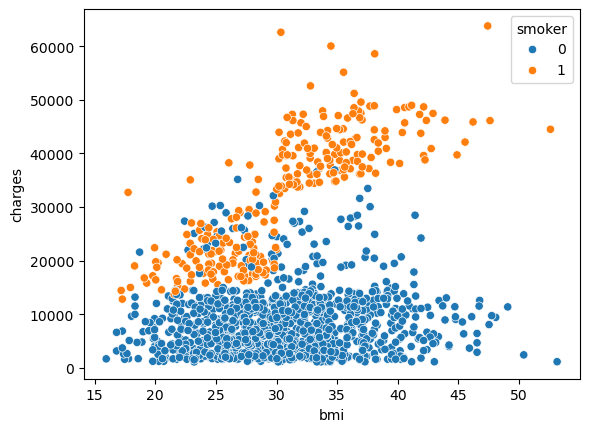

In [7]:
sns.scatterplot(insurance_data,x="bmi",y="charges",hue="smoker")

In [8]:
insurance_data["log_charges"] = np.log(insurance_data["charges"])

In [9]:
insurance_data

,age,sex,bmi,children,smoker,region,charges,log_charges
0,19,1,27.900,0,1,southwest,16884.92400,9.734176
1,18,0,33.770,1,0,southeast,1725.55230,7.453302
2,28,0,33.000,3,0,southeast,4449.46200,8.400538
3,33,0,22.705,0,0,northwest,21984.47061,9.998092
4,32,0,28.880,0,0,northwest,3866.85520,8.260197
...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,northwest,10600.54830,9.268661
1334,18,1,31.920,0,0,northeast,2205.98080,7.698927
1335,18,1,36.850,0,0,southeast,1629.83350,7.396233
1336,21,1,25.800,0,0,southwest,2007.94500,7.604867


In [10]:
insurance_data["age_smoker"] = insurance_data["age"] * insurance_data["smoker"]
insurance_data["bmi_smoker"] = insurance_data["bmi"] * insurance_data["smoker"]


In [11]:
insurance_data

,age,sex,bmi,children,smoker,region,charges,log_charges,age_smoker,bmi_smoker
0,19,1,27.900,0,1,southwest,16884.92400,9.734176,19,27.90
1,18,0,33.770,1,0,southeast,1725.55230,7.453302,0,0.00
2,28,0,33.000,3,0,southeast,4449.46200,8.400538,0,0.00
3,33,0,22.705,0,0,northwest,21984.47061,9.998092,0,0.00
4,32,0,28.880,0,0,northwest,3866.85520,8.260197,0,0.00
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,northwest,10600.54830,9.268661,0,0.00
1334,18,1,31.920,0,0,northeast,2205.98080,7.698927,0,0.00
1335,18,1,36.850,0,0,southeast,1629.83350,7.396233,0,0.00
1336,21,1,25.800,0,0,southwest,2007.94500,7.604867,0,0.00


In [12]:
from sklearn.model_selection import train_test_split

In [13]:
X = insurance_data.drop(columns=["charges","region","log_charges"])
Y = insurance_data["log_charges"]

In [14]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [15]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train,Y_train)

LinearRegression()

In [16]:
Y_pred_log = model.predict(X_test)
Y_pred = np.exp(Y_pred_log)

In [17]:
Y_pred[:5]

array([ 9527.88094682,  5338.40037382, 28005.46169415, 10126.13900779,
       23547.68686732])

In [18]:
Y_test_actual =np.exp(Y_test)
Y_test_actual

764      9095.06825
887      5272.17580
890     29330.98315
1293     9301.89355
259     33750.29180
           ...     
109     47055.53210
575     12222.89830
535      6067.12675
543     63770.42801
846      9872.70100
Name: log_charges, Length: 268, dtype: float64

In [19]:
from sklearn.metrics import r2_score

In [20]:
r_squared_value = r2_score(Y_test,y_pred=Y_pred_log)

In [21]:
n = X_test.shape[0]
p = X_test.shape[1]
adjusted_r_squared_value = 1- ((1-r_squared_value)*(n-1)/(n-p-1))

In [22]:
r_squared_value,adjusted_r_squared_value

(0.8485395042091619, 0.8444617216301777)

In [23]:
X_test.shape

(268, 7)

In [24]:
print("R2",r_squared_value)
print("Adj R2",adjusted_r_squared_value)

R2 0.8485395042091619
Adj R2 0.8444617216301777


In [25]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(Y_test_actual, Y_pred)
print("MSE (original scale):", mse)


MSE (original scale): 29346497.685475964


In [26]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(Y_test_actual, Y_pred)
print(mae)


2668.480406416264


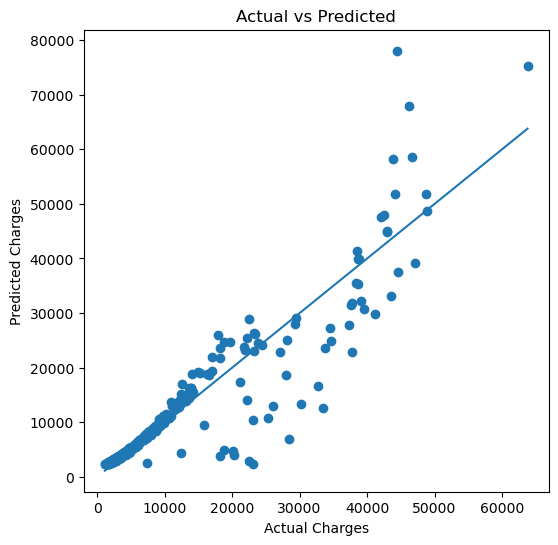

ValueError: Could not interpret value `` for `x`. An entry with this name does not appear in `data`.

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(Y_test_actual, Y_pred)
plt.plot([Y_test_actual.min(), Y_test_actual.max()],
         [Y_test_actual.min(), Y_test_actual.max()])
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted")
plt.show()

sns.scatterplot(insurance_data,x="")

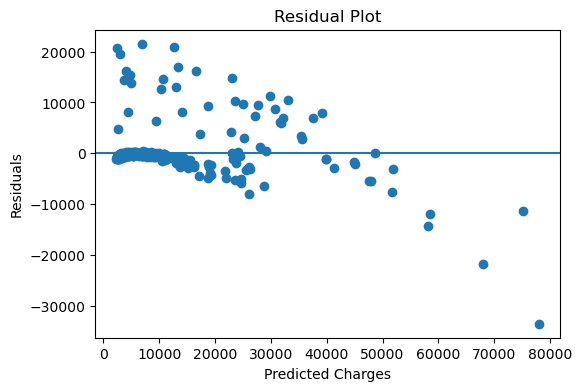

In [ ]:
residuals = Y_test_actual - Y_pred

plt.figure(figsize=(6,4))
plt.scatter(Y_pred, residuals)
plt.axhline(0)
plt.xlabel("Predicted Charges")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()


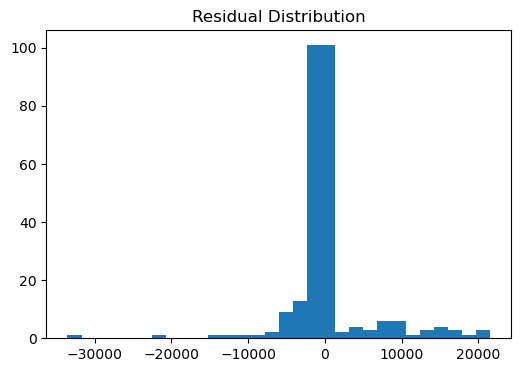

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(residuals, bins=30)
plt.title("Residual Distribution")
plt.show()


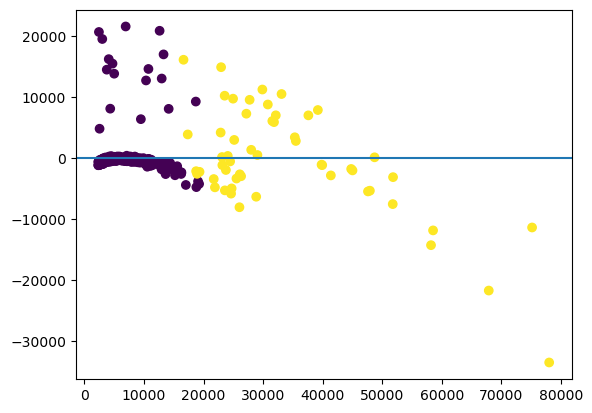

In [ ]:
plt.scatter(Y_pred, residuals, c=X_test["smoker"])
plt.axhline(0)
plt.show()


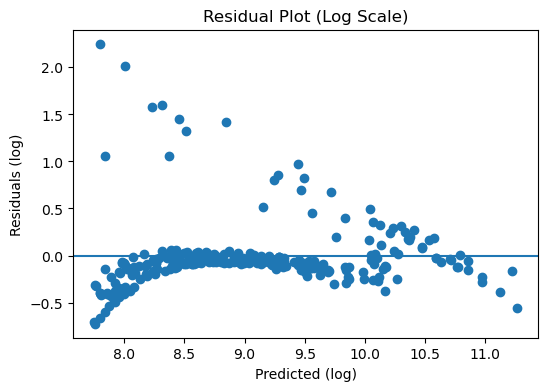

In [29]:
residuals_log = Y_test - Y_pred_log

plt.figure(figsize=(6,4))
plt.scatter(Y_pred_log, residuals_log)
plt.axhline(0)

plt.xlabel("Predicted (log)")
plt.ylabel("Residuals (log)")
plt.title("Residual Plot (Log Scale)")

plt.show()
